# Imports

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from utility.utils import data_distribution_frame, recall_at_precision, optimal_threshold, reports_fig_dir, models_dir

from sklearn.metrics import (
    precision_recall_curve, classification_report, confusion_matrix, 
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay
)
from sklearn.model_selection import train_test_split, StratifiedKFold, LearningCurveDisplay
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline

from sklearn.ensemble import HistGradientBoostingClassifier

np.random.seed(37)

In [2]:
data = pd.read_csv('../data/application_train.csv')

In [3]:
target = data['TARGET']
data.drop(columns=['TARGET'], inplace=True)

# Train Test Split

In [4]:
data_train, data_test, target_train, target_test = train_test_split(data, target, test_size=0.20, shuffle=True, stratify=target, random_state=37)

In [5]:
print(f'data_train = {data_train.shape}')
print(f'target_train = {target_train.shape}')
print(f'data_test = {data_test.shape}')
print(f'target_test = {target_test.shape}')

data_train = (246008, 121)
target_train = (246008,)
data_test = (61503, 121)
target_test = (61503,)


In [6]:
data_distribution_frame(target_train)

,value counts,percent of total
0,226148,92%
1,19860,8%


In [7]:
data_distribution_frame(target_test)

,value counts,percent of total
0,56538,92%
1,4965,8%


# Preprocessing Pipeline

In [8]:
cat_columns = make_column_selector(dtype_include='object')(data_train)
num_columns = make_column_selector(dtype_exclude='object')(data_train)

In [9]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(sparse_output=False, handle_unknown='infrequent_if_exist', min_frequency=1)
)

cat_pipeline

,steps,"[('simpleimputer', ...), ('onehotencoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [10]:
num_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'), RobustScaler()
)

num_pipeline

,steps,"[('simpleimputer', ...), ('robustscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,with_centering,True


In [11]:
preprocessing = ColumnTransformer(transformers=[
    ('nums', num_pipeline, num_columns),
    ('cat_ohe', cat_pipeline, cat_columns),
], remainder='passthrough', n_jobs=-1)

preprocessing

,transformers,"[('nums', ...), ('cat_ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


# Model Pipeline

In [12]:
model = make_pipeline(
    preprocessing, HistGradientBoostingClassifier(
    class_weight='balanced', random_state=37,
    n_iter_no_change = 10, max_leaf_nodes = 36,
    max_iter = 139, max_bins = 169,
    learning_rate = 0.3
    )
)

model

,steps,"[('columntransformer', ...), ('histgradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nums', ...), ('cat_ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Model Training

In [13]:
model.fit(data_train, target_train)

,steps,"[('columntransformer', ...), ('histgradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nums', ...), ('cat_ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Model Evaluation

In [14]:
target_pred = model.predict(data_test)

## Classification Report

In [15]:
target_names = ['non-defaults', 'defaults']

pd.DataFrame(classification_report(target_test, target_pred, output_dict=True, target_names=target_names))

,non-defaults,defaults,accuracy,macro avg,weighted avg
precision,0.960351,0.166683,0.703706,0.563517,0.896280
recall,0.706870,0.667674,0.703706,0.687272,0.703706
f1-score,0.814341,0.266769,0.703706,0.540555,0.770137
support,56538.000000,4965.000000,0.703706,61503.000000,61503.000000


## Confusion Matrix

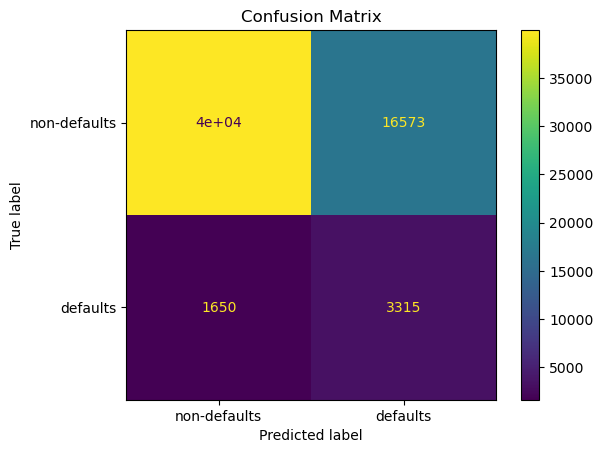

In [16]:
cm = confusion_matrix(target_test, target_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot()
plt.title('Confusion Matrix')
plt.savefig(f"{reports_fig_dir}/confusion_matrix.png")
plt.show()

## ROC Curve

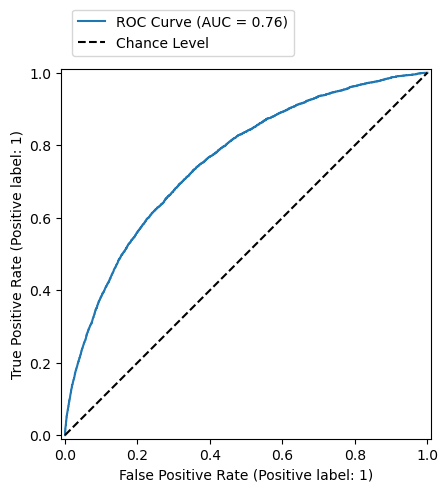

In [17]:
RocCurveDisplay.from_estimator(
        estimator=model,
        X=data_test, y=target_test,
        pos_label=1, response_method='auto',
        name='ROC Curve', plot_chance_level=True,
        chance_level_kw={'label':'Chance Level'}
    )
plt.legend(bbox_to_anchor=(0.01, 1.18), loc='upper left')
plt.savefig(f"{reports_fig_dir}/roc_curve.png")
plt.show()

## PR Curve

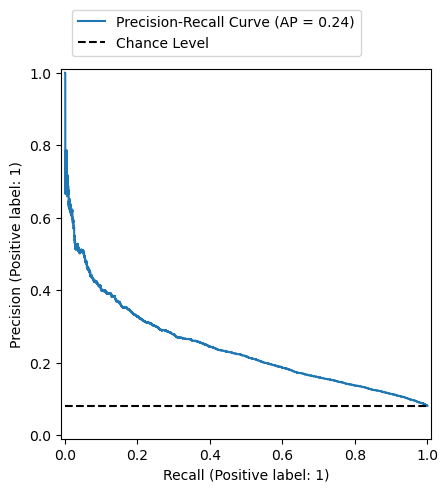

In [18]:
PrecisionRecallDisplay.from_estimator(
        estimator=model,
        X=data_test, y=target_test,
        pos_label=1, response_method='auto',
        name='Precision-Recall Curve', plot_chance_level=True,
        chance_level_kw={'label':'Chance Level'}
    )
plt.legend(bbox_to_anchor=(0.01, 1.18), loc='upper left')
plt.savefig(f"{reports_fig_dir}/pr_curve.png")
plt.show()

## Optimal Threshold

In [19]:
optimal_thresh = optimal_threshold(model, data_test, target_test)
print(f'optimal_threshold = {optimal_thresh:.3f}')

optimal_threshold = 0.063


## Recall@Precision=0.60

In [20]:
print(f'Recall@Precision=0.60: {recall_at_precision(model, data_test, target_test, 0.60):.3f}')

Recall@Precision=0.60: 0.021


## Confusion Matrix at optimal Threshold

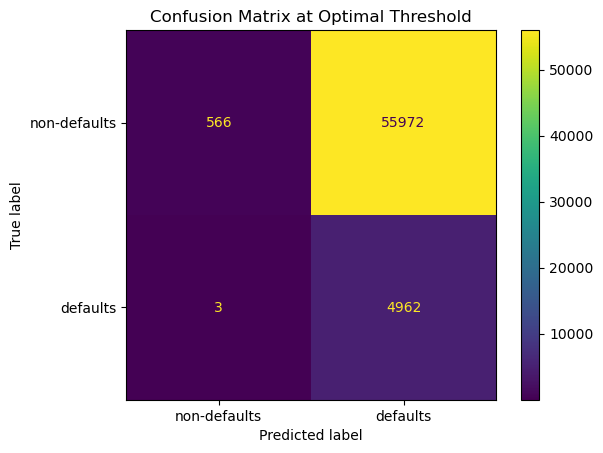

In [21]:
target_pred_optimal = (model.predict_proba(data_test)[:,1] > optimal_thresh).astype(int)
cm_optimal = confusion_matrix(target_test, target_pred_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_optimal, display_labels=target_names)
disp.plot()
plt.title('Confusion Matrix at Optimal Threshold')
plt.savefig(f"{reports_fig_dir}/confusion_matrix@optimal_threshold.png")
plt.show()

# Model Persistance

In [22]:
joblib.dump(model, f"{models_dir}/loanguard.pkl")

['C:\\Users\\turningpointKS\\ml_world\\portfolio-projects\\loanguard\\models/loanguard.pkl']